# Git cloning

In [1]:
!nvidia-smi

Wed May  6 18:11:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%capture
!wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb
!apt update
!apt install ./nsight-systems-2023.2.3_2023.2.3.1001-1_amd64.deb
!apt --fix-broken install

In [33]:
%cd /content/
!git clone https://github.com/stasostyk/DSMC.git
%cd /content/DSMC/
!git checkout cuda_naive
!git pull

/content
fatal: destination path 'DSMC' already exists and is not an empty directory.
/content/DSMC
Already on 'cuda_naive'
Your branch is up to date with 'origin/cuda_naive'.
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 409 bytes | 136.00 KiB/s, done.
From https://github.com/stasostyk/DSMC
   934f8d4..8b0f914  cuda_naive -> origin/cuda_naive
Updating 934f8d4..8b0f914
Fast-forward
 cuda/src/simulation.cu | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


# Serial version

In [ ]:
%cd /content/DSMC/serial/
!mkdir build
%cd build

# serial version
!cmake .. && make -j4
!./DSMC_ball
!../../plot.py ball fields_avg.dat ball.png

/content/DSMC/serial
mkdir: cannot create directory ‘build’: File exists
/content/DSMC/serial/build
-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /content/DSMC/serial/build
[100%] Built target DSMC_ball
[100%] Built target DSMC_wing
Running Ball case.
INITIALIZATION. Elapsed time: 60.0684 ms
step=0
  NP=199864
  mean_u=(1.051331e+03, 8.915756e-02, 6.262206e-01)
  T=2.035637e+02
  totalCollisions = 7691
step=200
  NP=212595
  mean_u=(9.658937e+02, -4.001870e+00, 2.067984e-01)
  T=3.542569e+02
  totalCollisions = 1864878
step=400
  NP=213327
  mean_u=(9.638896e+02, -4.761209e+00, 1.183419e-01)
  T=3.560333e+02
  totalCollisions = 3893454
step=600
  NP=214193
  mean_u=(9.626265e+02, -3.952623e+00, 5.376362e-01)
  T=3.564924e+02
  totalCollisions = 5927537
step=800
  NP=212963
  mean_u=(9.629235e+02, -4.345751e+00, 8.394846e-01)
  T=3.566081e+02
  totalCollisions = 7966521
step=1000
  NP=213385
  mean_u=(9.617663e+02, -5.242084e+00, -4.977259e-01

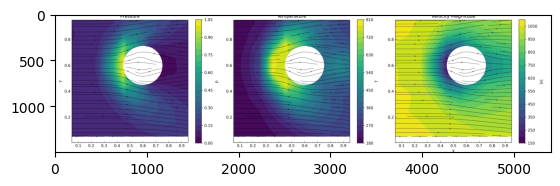

In [ ]:
import matplotlib.pyplot as plt
img = plt.imread("ball.png")
plt.imshow(img)

# CUDA execution


In [34]:
%cd /content/DSMC/cuda/
!rm -rf build/*
!mkdir -p build
%cd build
!cmake ..
!cmake --build .

/content/DSMC/cuda
/content/DSMC/cuda/build
-- The C compiler identification is GNU 11.4.0
-- The CUDA compiler identification is NVIDIA 12.8.93 with host compiler GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CUDA compiler ABI info
-- Detecting CUDA compiler ABI info - done
-- Check for working CUDA compiler: /usr/local/cuda/bin/nvcc - skipped
-- Detecting CUDA compile features
-- Detecting CUDA compile features - done
-- Configuring done (2.4s)
-- Generating done (0.0s)
-- Build files have been written to: /content/DSMC/cuda/build
[ 10%] Building CUDA object CMakeFiles/DSMC_ball.dir/src/main.cu.o
[ 20%] Building CUDA object CMakeFiles/DSMC_ball.dir/src/math_utils.cu.o
[ 30%] Building CUDA object CMakeFiles/DSMC_ball.dir/src/config.cu.o
[ 40%] Building CUDA object CMakeFiles/DSMC_ball.dir/src/collider.cu.o
[ 50

In [35]:
%cd /content/DSMC/cuda/build/
!./DSMC_ball

/content/DSMC/cuda/build
Running Ball case.
INITIALIZATION. Elapsed time: 320.3669 ms
step=0
  NP=200192
  mean_u=(1.050875e+03, -3.168370e-01, 1.132611e-01)
  T=2.034892e+02
  totalCollisions = 7673
step=200
  NP=212463
  mean_u=(9.656095e+02, -4.894715e+00, 8.548922e-02)
  T=3.537255e+02
  totalCollisions = 1864288
step=400
  NP=214193
  mean_u=(9.614726e+02, -5.276585e+00, -6.698033e-01)
  T=3.583958e+02
  totalCollisions = 3906657
step=600
  NP=212924
  mean_u=(9.624555e+02, -4.426649e+00, 2.121691e-01)
  T=3.571821e+02
  totalCollisions = 5947082
step=800
  NP=212709
  mean_u=(9.619273e+02, -5.085412e+00, 3.082775e-01)
  T=3.571893e+02
  totalCollisions = 7967905
step=1000
  NP=213460
  mean_u=(9.629241e+02, -4.769073e+00, -8.801248e-02)
  T=3.559625e+02
  totalCollisions = 10001047
step=1200
  NP=213862
  mean_u=(9.629246e+02, -5.000066e+00, -1.333617e+00)
  T=3.561710e+02
  totalCollisions = 12040016
step=1400
  NP=213844
  mean_u=(9.624628e+02, -5.919996e+00, -4.039343e-01)
  T

/content/DSMC/cuda/build


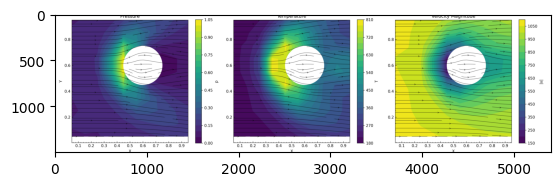

In [36]:
%cd /content/DSMC/cuda/build/
!../../plot.py ball fields_avg.dat ball.png
import matplotlib.pyplot as plt
img = plt.imread("ball.png")
plt.imshow(img)

In [ ]:
%cd /content/DSMC/cuda/build/
!nsys profile --stats=true ./DSMC_ball

/content/DSMC/cuda/build
Running Ball case.
INITIALIZATION. Elapsed time: 609.0193 ms
step=0
  NP=200192
  mean_u=(1.050860e+03, -3.722901e-01, 1.014430e-01)
  T=2.035697e+02
  totalCollisions = 7687
step=200
  NP=213117
  mean_u=(9.636418e+02, -4.108273e+00, -1.743399e-01)
  T=3.564253e+02
  totalCollisions = 1871500
step=400
  NP=214344
  mean_u=(9.622462e+02, -5.703933e+00, -5.951743e-01)
  T=3.567777e+02
  totalCollisions = 3917176
step=600
  NP=213231
  mean_u=(9.631203e+02, -4.403224e+00, 4.005909e-01)
  T=3.556787e+02
  totalCollisions = 5957749
step=800
  NP=212951
  mean_u=(9.619239e+02, -5.164365e+00, 6.412104e-01)
  T=3.565232e+02
  totalCollisions = 7977585
step=1000
  NP=213235
  mean_u=(9.634204e+02, -5.281979e+00, -9.470007e-01)
  T=3.557567e+02
  totalCollisions = 10011666
step=1200
  NP=214152
  mean_u=(9.617318e+02, -4.635471e+00, -6.732540e-01)
  T=3.567633e+02
  totalCollisions = 12050200
step=1400
  NP=213869
  mean_u=(9.641657e+02, -5.801821e+00, 2.658346e-01)
  T